In [1]:
import sys, os

# always set working directory to GhostMTFormer root regardless of where notebook runs
project_root = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
os.chdir(project_root)
sys.path.insert(0, project_root)

print(f'Working directory: {os.getcwd()}')

import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

from src.dataset import get_dataloaders, load_config
from src.model.ghostmtformer import GhostMTFormer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Working directory: g:\GhostMTFormer


g:\GhostMTFormer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
#cell 2

cfg   = load_config('configs/default.yaml')
model = GhostMTFormer(cfg).to(device)
ckpt  = torch.load('checkpoints/best_model.pth', map_location=device)
model.load_state_dict(ckpt['model'])
model.eval()
print(f'Loaded checkpoint — epoch {ckpt["epoch"]} | best Dice {ckpt["best_dice"]:.4f}')

Loaded checkpoint — epoch 69 | best Dice 0.9428


In [3]:
#cell 3

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image):
        self.model.zero_grad()
        outputs = self.model(image)
        score   = outputs['seg'].mean()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam)
        cam     = torch.nn.functional.interpolate(
            cam, size=image.shape[2:], mode='bilinear', align_corners=False
        )
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, outputs

target_layer = model.decoder.stage1.conv.block[-3]
gradcam      = GradCAM(model, target_layer)
print('Grad-CAM hooked to decoder stage 1')

Grad-CAM hooked to decoder stage 1


In [4]:
#cell 4
def mc_uncertainty(model, image, n_passes=25):
    for m in model.modules():
        if isinstance(m, torch.nn.Dropout2d):
            m.train()
    preds = []
    with torch.no_grad():
        for _ in range(n_passes):
            out  = model(image)
            prob = torch.sigmoid(out['seg'])
            preds.append(prob.cpu())
    model.eval()
    preds       = torch.stack(preds)
    mean_pred   = preds.mean(dim=0).squeeze().numpy()
    uncertainty = preds.std(dim=0).squeeze().numpy()
    return mean_pred, uncertainty

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def denorm(t):
    img = t.squeeze().permute(1,2,0).cpu().numpy()
    return (img * std + mean).clip(0, 1)

  Total valid pairs: 10015
  Train: 8012 | Val: 1001 | Test: 1002


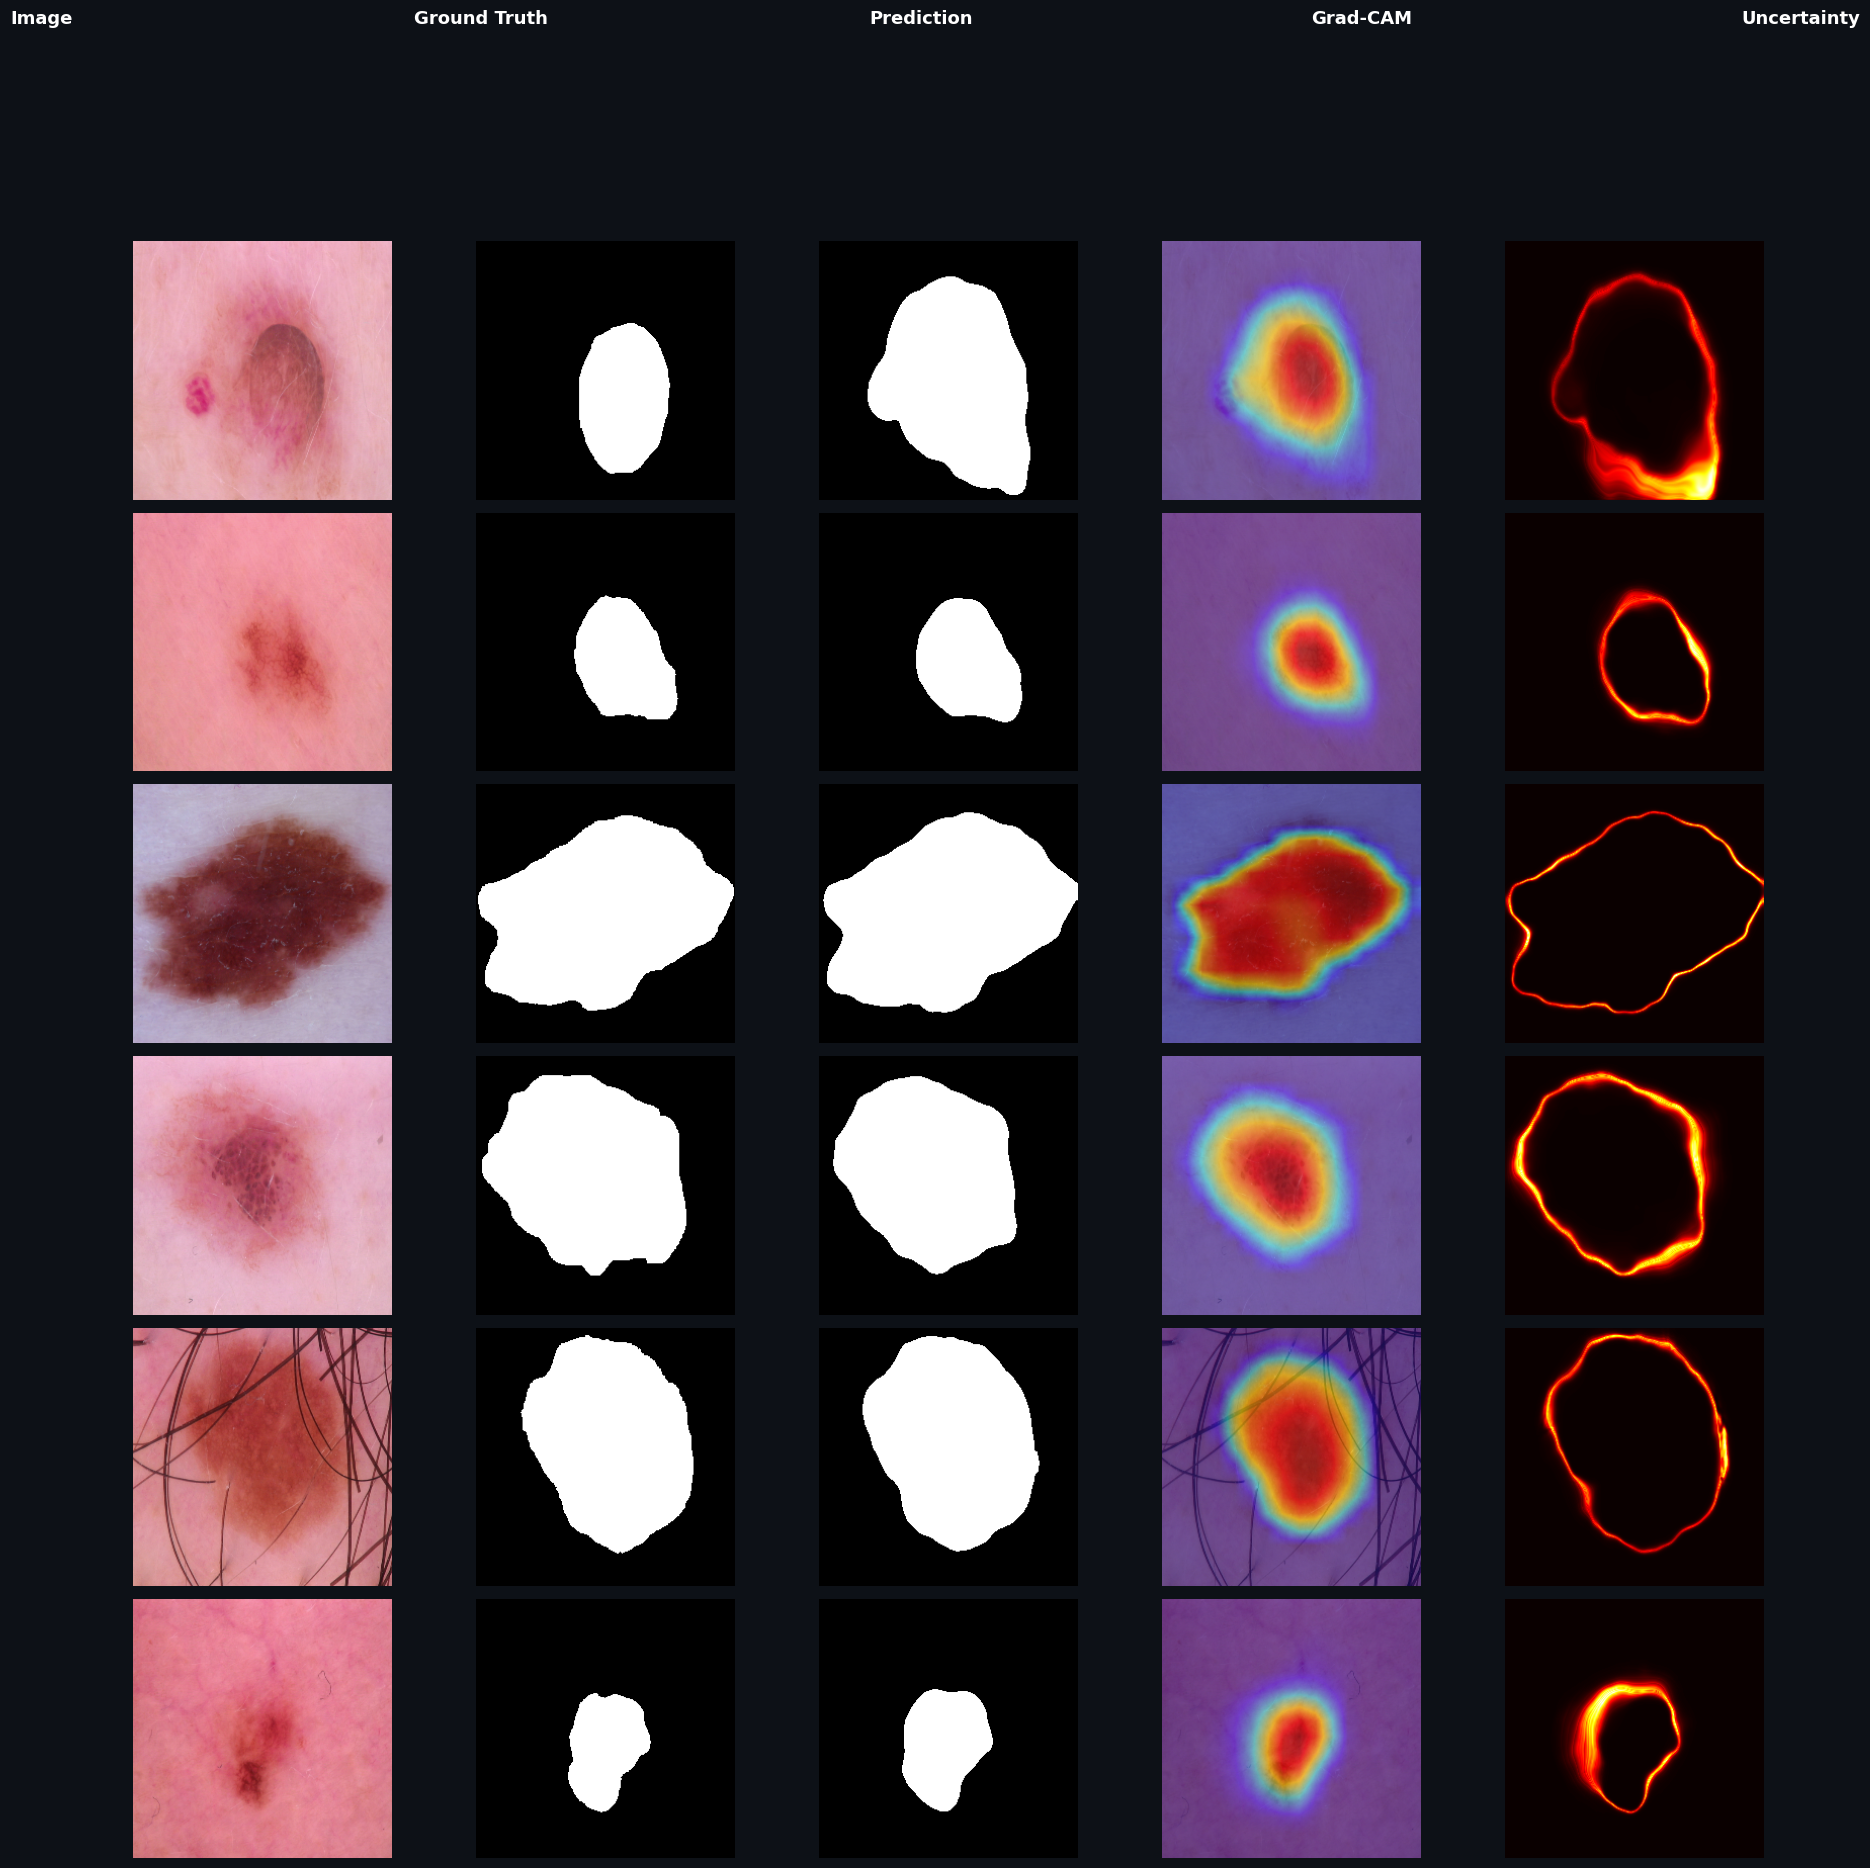

Saved to results/gradcam_analysis.png


In [5]:
#cell 5
_, _, test_loader = get_dataloaders(cfg)
images_batch, masks_batch = next(iter(test_loader))

n_show = 6
fig = plt.figure(figsize=(22, n_show * 3.5))
fig.patch.set_facecolor('#0d1117')

col_titles = ['Image', 'Ground Truth', 'Prediction', 'Grad-CAM', 'Uncertainty']
for j, title in enumerate(col_titles):
    fig.text((j + 0.5) / 5, 0.99, title, ha='center', va='top',
             fontsize=13, fontweight='bold', color='white')

for i in range(n_show):
    image = images_batch[i].unsqueeze(0).to(device)
    mask  = masks_batch[i].squeeze().numpy()

    cam, outputs = gradcam.generate(image)
    pred = torch.sigmoid(outputs['seg']).squeeze().detach().cpu().numpy()
    mean_pred, uncertainty = mc_uncertainty(model, image)
    img_np = denorm(image)

    axes = [fig.add_subplot(n_show, 5, i*5 + j + 1) for j in range(5)]
    axes[0].imshow(img_np)
    axes[1].imshow(mask,       cmap='gray')
    axes[2].imshow(pred > 0.5, cmap='gray')

    heatmap = cv2.applyColorMap(
        (cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    axes[3].imshow(img_np * 0.5 + heatmap * 0.5)
    axes[4].imshow(uncertainty, cmap='hot')

    for ax in axes:
        ax.axis('off')
        ax.set_facecolor('#0d1117')

plt.subplots_adjust(wspace=0.03, hspace=0.05)
plt.savefig('results/gradcam_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved to results/gradcam_analysis.png')